Tên: Lê Văn Huy
MSSV: 070206007733

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

In [2]:
#1. Nạp dự liệu iris vào bộ nhớ và hiển thị thông tin về số thuộc tính (dimensionality), số objects (size).
breast_cancer = load_breast_cancer()
x = breast_cancer.data
y = breast_cancer.target
print(f"Object: {x.shape[0]}")
print(f"Dimensionality: {x.shape[1]}")

Object: 569
Dimensionality: 30


In [3]:
#2. Đặt nhãn (label) cho dữ liệu đã nạp và hiển thị số lớp (classes)
name = breast_cancer.target_names
num = len(name)
print("Đặt nhãn thành công")
print(f"Số lớp: {num}")
for i, name_flower in enumerate(name):
    print(f"Name: {name_flower} | Nhãn {i}: {np.sum(y==i)} mẫu")

Đặt nhãn thành công
Số lớp: 2
Name: malignant | Nhãn 0: 212 mẫu
Name: benign | Nhãn 1: 357 mẫu


In [4]:
#3. Tách dữ liệu thành hai phần: training data(70%) và test data (30%)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=40, stratify=y
)
print(f"Traning data 70%: {x_train.shape[0]} mẫu")
print(f"Test data 30%: {x_test.shape[0]} mẫu")

Traning data 70%: 398 mẫu
Test data 30%: 171 mẫu


In [5]:
#4. Chuẩn hóa dữ liệu với StandardScaler
scl = StandardScaler()
x_train_scl = scl.fit_transform(x_train)
x_test_scl = scl.transform(x_test)
print("Đã chuẩn hóa dữ liệu xong")

Đã chuẩn hóa dữ liệu xong


In [6]:
#5. Tạo và huấn luyện mô hình với training data
clf = DecisionTreeClassifier(random_state=40)
clf.fit(x_train_scl, y_train)
print("Huấn luyện ok")

Huấn luyện ok


Accurary: 0.959
F1-Score: 0.956


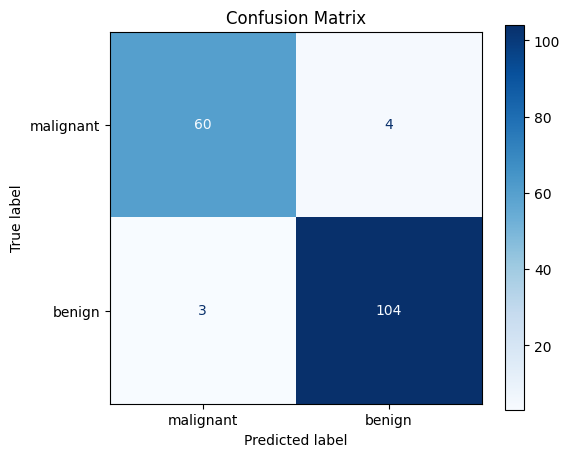

In [7]:
#6. Test và đánh giá độ chính xác của mô mình, yêu cầu hiển thị ma trận confusion matrix, accuracy, f-score
y_predict = clf.predict(x_test_scl)
calc_accuracy = accuracy_score(y_test, y_predict)
macro = f1_score(y_test, y_predict, average='macro')
matrix = confusion_matrix(y_test, y_predict)
print(f"Accurary: {calc_accuracy:.3f}")
print(f"F1-Score: {macro:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=name)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

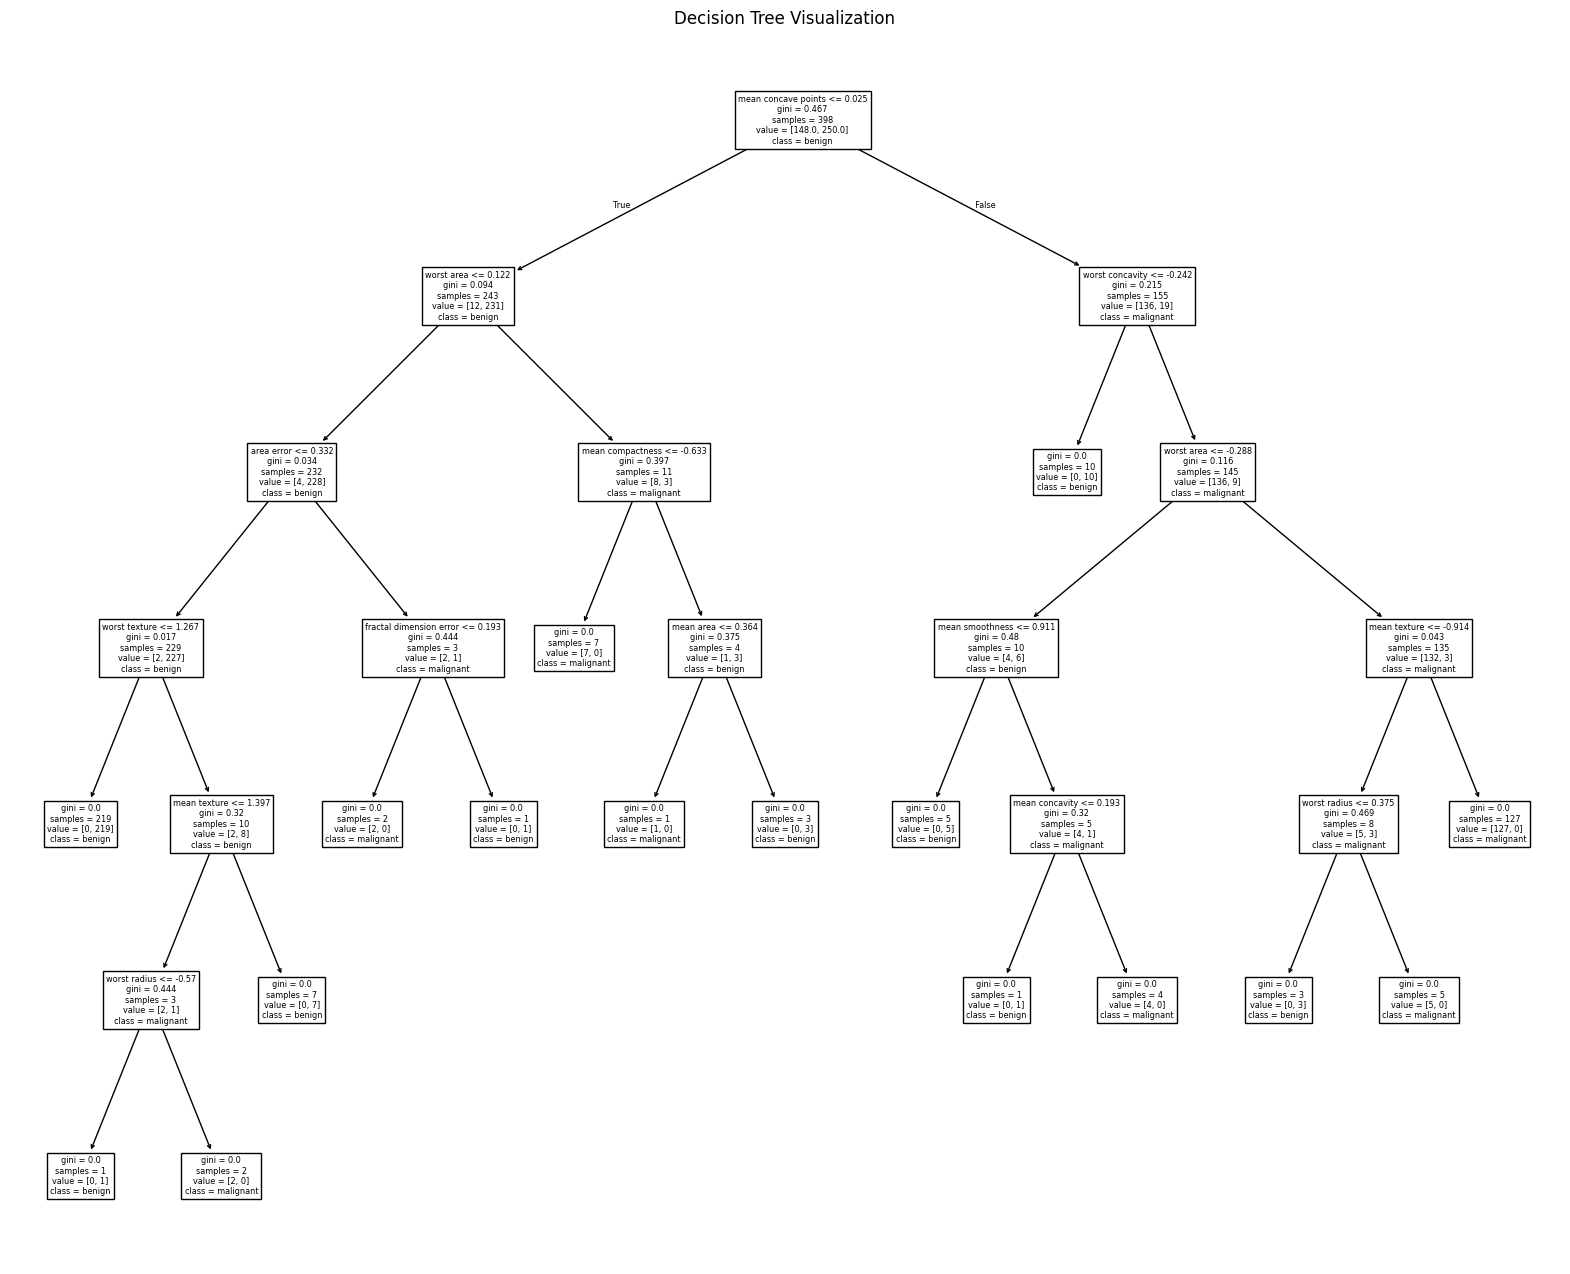

In [8]:
#7. Trực quan hóa cây quyết định
plt.figure(figsize=(20, 16))
plot_tree(
    clf, 
    feature_names=breast_cancer.feature_names, 
    class_names=breast_cancer.target_names, 
)
plt.title("Decision Tree Visualization")
plt.show()